In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


df = pd.read_csv('Online_Retail.csv', encoding="utf-8-sig")
print(df.shape)
df.head()

(541909, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,01-12-2010 08:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,01-12-2010 08:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,01-12-2010 08:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,01-12-2010 08:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,01-12-2010 08:26,3.39,17850.0,United Kingdom


In [27]:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

Shape: (536641, 9)

Columns:
Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country', 'TotalPrice'],
      dtype='object')

Missing Values:
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135037
Country             0
TotalPrice          0
dtype: int64

Duplicate Rows:
0


In [26]:
df = df.drop_duplicates()

In [21]:
print("Shape after removing duplicates:", df.shape)
print("Duplicate Rows:", df.duplicated().sum())

Shape after removing duplicates: (536641, 9)
Duplicate Rows: 0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 536641 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    536641 non-null  object 
 1   StockCode    536641 non-null  object 
 2   Description  535187 non-null  object 
 3   Quantity     536641 non-null  int64  
 4   InvoiceDate  536641 non-null  object 
 5   UnitPrice    536641 non-null  float64
 6   CustomerID   401604 non-null  float64
 7   Country      536641 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 36.8+ MB


In [9]:
df["InvoiceDate"] = pd.to_datetime(
    df["InvoiceDate"],
    format="%d-%m-%Y %H:%M"
)

In [19]:
df["CustomerID"].isnull().sum()

np.int64(135037)

In [28]:
df = df.dropna(subset=["CustomerID"])
df["CustomerID"] = df["CustomerID"].astype(int)

df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 401604 entries, 0 to 541908
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    401604 non-null  object        
 1   StockCode    401604 non-null  object        
 2   Description  401604 non-null  object        
 3   Quantity     401604 non-null  int64         
 4   InvoiceDate  401604 non-null  datetime64[ns]
 5   UnitPrice    401604 non-null  float64       
 6   CustomerID   401604 non-null  int64         
 7   Country      401604 non-null  object        
 8   TotalPrice   401604 non-null  float64       
dtypes: datetime64[ns](1), float64(2), int64(2), object(4)
memory usage: 30.6+ MB


In [29]:
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34


In [30]:
print("Quantity <= 0:", (df["Quantity"] <= 0).sum())
print("UnitPrice <= 0:", (df["UnitPrice"] <= 0).sum())
print("TotalPrice <= 0:", (df["TotalPrice"] <= 0).sum())

Quantity <= 0: 8872
UnitPrice <= 0: 40
TotalPrice <= 0: 8912


In [31]:
df[["Quantity", "UnitPrice", "TotalPrice"]].head(10)


,Quantity,UnitPrice,TotalPrice
0,6,2.55,15.30
1,6,3.39,20.34
2,8,2.75,22.00
3,6,3.39,20.34
4,6,3.39,20.34
5,2,7.65,15.30
6,6,4.25,25.50
7,6,1.85,11.10
8,6,1.85,11.10
9,32,1.69,54.08


In [32]:
(df["TotalPrice"] == df["Quantity"] * df["UnitPrice"]).all()

np.True_

In [33]:
total_revenue = df["TotalPrice"].sum()
total_orders = df["InvoiceNo"].nunique()
total_customers = df["CustomerID"].nunique()
total_products = df["StockCode"].nunique()

print("Total Revenue:", round(total_revenue, 2))
print("Total Orders:", total_orders)
print("Total Customers:", total_customers)
print("Total Products:", total_products)

Total Revenue: 8278519.42
Total Orders: 22190
Total Customers: 4372
Total Products: 3684


In [34]:
average_order_value = total_revenue / total_orders
print("Average Order Value:", round(average_order_value, 2))

Average Order Value: 373.07


In [35]:
country_revenue = (
    df.groupby("Country")["TotalPrice"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)
print(country_revenue)

Country
United Kingdom    6747156.154
Netherlands        284661.540
EIRE               250001.780
Germany            221509.470
France             196626.050
Australia          137009.770
Switzerland         55739.400
Spain               54756.030
Belgium             40910.960
Sweden              36585.410
Name: TotalPrice, dtype: float64


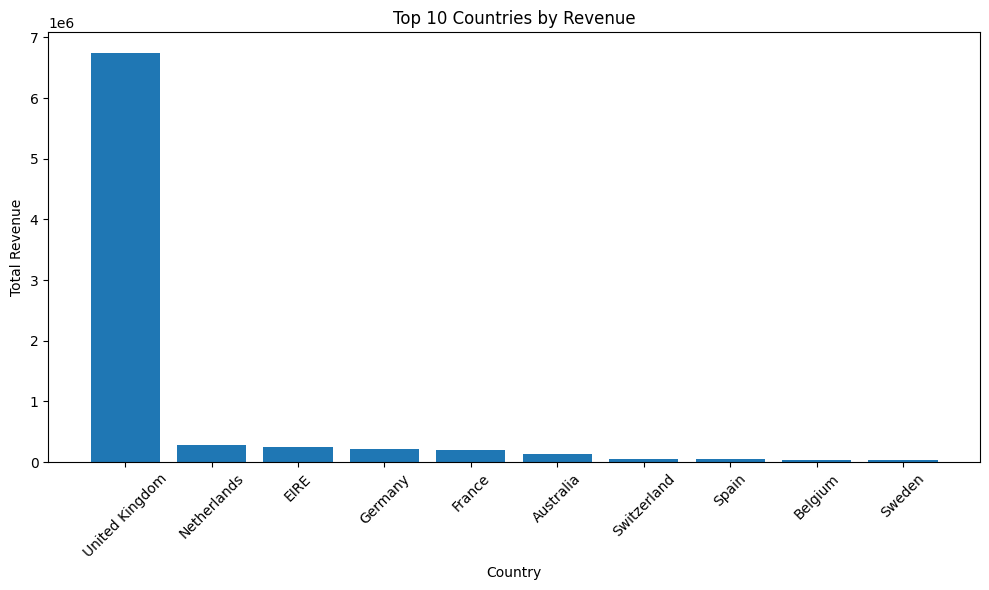

In [36]:
plt.figure(figsize=(10, 6))
plt.bar(country_revenue.index,country_revenue.values)
plt.title("Top 10 Countries by Revenue")
plt.xlabel("Country")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [37]:
df["Month"] = df["InvoiceDate"].dt.to_period("M")

In [38]:
monthly_revenue = (
    df.groupby("Month")["TotalPrice"]
    .sum()
    .reset_index())

print(monthly_revenue)

      Month   TotalPrice
0   2010-12   552372.860
1   2011-01   473731.900
2   2011-02   435534.070
3   2011-03   578576.210
4   2011-04   425222.671
5   2011-05   647011.670
6   2011-06   606862.520
7   2011-07   573112.321
8   2011-08   615078.090
9   2011-09   929356.232
10  2011-10   973306.380
11  2011-11  1126815.070
12  2011-12   341539.430


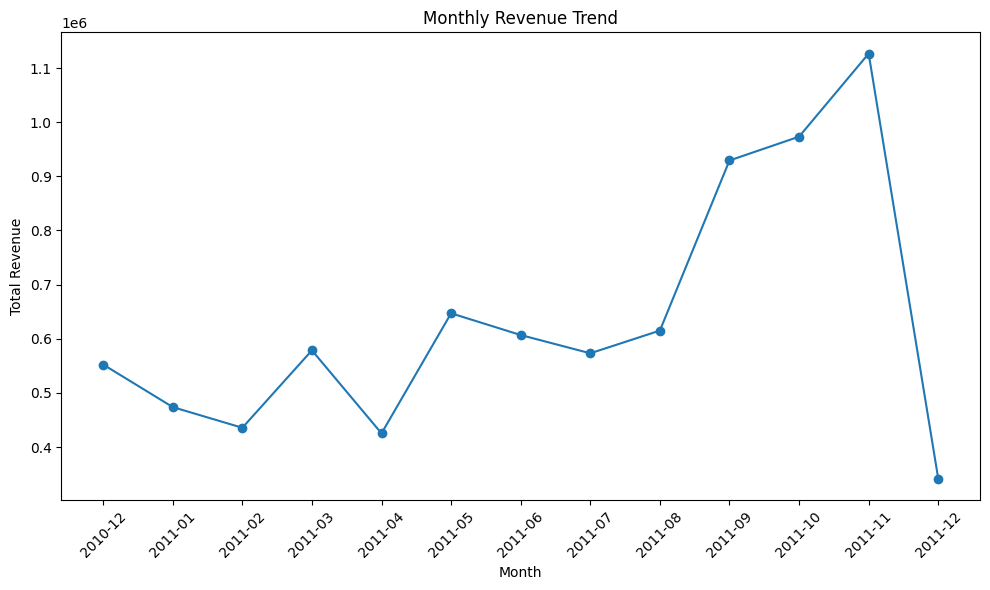

In [39]:
plt.figure(figsize=(10, 6))

plt.plot(
    monthly_revenue["Month"].astype(str),
    monthly_revenue["TotalPrice"],
    marker="o"
)

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Total Revenue")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [40]:
highest_month = monthly_revenue.loc[
    monthly_revenue["TotalPrice"].idxmax()]
lowest_month = monthly_revenue.loc[
    monthly_revenue["TotalPrice"].idxmin()]
print("Highest Revenue Month:")
print(highest_month)
print("\nLowest Revenue Month:")
print(lowest_month)

Highest Revenue Month:
Month            2011-11
TotalPrice    1126815.07
Name: 11, dtype: object

Lowest Revenue Month:
Month           2011-12
TotalPrice    341539.43
Name: 12, dtype: object


In [41]:
customer_data = (
    df.groupby("CustomerID")
    .agg(
        TotalRevenue=("TotalPrice", "sum"),
        TotalOrders=("InvoiceNo", "nunique"),
        TotalQuantity=("Quantity", "sum")).reset_index())

customer_data.head()

,CustomerID,TotalRevenue,TotalOrders,TotalQuantity
0,12346,0.00,2,0
1,12347,4310.00,7,2458
2,12348,1797.24,4,2341
3,12349,1757.55,1,631
4,12350,334.40,1,197


In [42]:
latest_date = df["InvoiceDate"].max()

print("Latest Date:", latest_date)

Latest Date: 2011-12-09 12:50:00


In [43]:
customer_recency = (
    df.groupby("CustomerID")["InvoiceDate"]
    .max()
    .reset_index()
)

customer_recency["Recency"] = (
    latest_date - customer_recency["InvoiceDate"]
).dt.days
customer_recency = customer_recency[["CustomerID", "Recency"]]
customer_recency.head()

,CustomerID,Recency
0,12346,325
1,12347,1
2,12348,74
3,12349,18
4,12350,309


In [44]:
customer_data = customer_data.merge(
    customer_recency,
    on="CustomerID"
)

customer_data.head()

,CustomerID,TotalRevenue,TotalOrders,TotalQuantity,Recency
0,12346,0.00,2,0,325
1,12347,4310.00,7,2458,1
2,12348,1797.24,4,2341,74
3,12349,1757.55,1,631,18
4,12350,334.40,1,197,309


In [47]:
# Query 2 - Monthly revenue trend
# Convert InvoiceDate to datetime
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'], format='%d-%m-%Y %H:%M')

# Create Month column
df['Month'] = df['InvoiceDate'].dt.to_period('M')

# Calculate monthly revenue
monthly_revenue = ( df.groupby('Month')['TotalPrice'].sum().reset_index())

monthly_revenue

,Month,TotalPrice
0,2010-12,552372.860
1,2011-01,473731.900
2,2011-02,435534.070
3,2011-03,578576.210
4,2011-04,425222.671
5,2011-05,647011.670
6,2011-06,606862.520
7,2011-07,573112.321
8,2011-08,615078.090
9,2011-09,929356.232


In [48]:
rfm = customer_data[
    ["CustomerID", "Recency", "TotalOrders", "TotalRevenue"]
]

rfm.head()

,CustomerID,Recency,TotalOrders,TotalRevenue
0,12346,325,2,0.00
1,12347,1,7,4310.00
2,12348,74,4,1797.24
3,12349,18,1,1757.55
4,12350,309,1,334.40


In [49]:
print(rfm.describe())

         CustomerID      Recency  TotalOrders   TotalRevenue
count   4372.000000  4372.000000  4372.000000    4372.000000
mean   15299.677722    91.047118     5.075480    1893.531433
std     1722.390705   100.765435     9.338754    8218.696204
min    12346.000000     0.000000     1.000000   -4287.630000
25%    13812.750000    16.000000     1.000000     291.795000
50%    15300.500000    49.000000     3.000000     644.070000
75%    16778.250000   142.000000     5.000000    1608.335000
max    18287.000000   373.000000   248.000000  279489.020000


In [50]:
rfm["R_Score"] = pd.qcut(
    rfm["Recency"],
    q=3,
    labels=[3, 2, 1]
)

rfm["F_Score"] = pd.qcut(
    rfm["TotalOrders"].rank(method="first"),
    q=3,
    labels=[1, 2, 3]
)

rfm["M_Score"] = pd.qcut(
    rfm["TotalRevenue"],
    q=3,
    labels=[1, 2, 3]
)

In [51]:
rfm["TotalOrders"].rank(method="first")

0       1314.0
1       3482.0
2       2621.0
3          1.0
4          2.0
         ...  
4367    1312.0
4368    1313.0
4369    2619.0
4370    4159.0
4371    2620.0
Name: TotalOrders, Length: 4372, dtype: float64

In [52]:
rfm["RFM_Score"] = (
    rfm["R_Score"].astype(int)
    + rfm["F_Score"].astype(int)
    + rfm["M_Score"].astype(int)
)

rfm.head()

,CustomerID,Recency,TotalOrders,TotalRevenue,R_Score,F_Score,M_Score,RFM_Score
0,12346,325,2,0.00,1,1,1,3
1,12347,1,7,4310.00,3,3,3,9
2,12348,74,4,1797.24,2,2,3,7
3,12349,18,1,1757.55,3,1,3,7
4,12350,309,1,334.40,1,1,1,3


In [53]:
rfm["Segment"] = pd.cut(
    rfm["RFM_Score"],
    bins=[2, 4, 6, 9],
    labels=["Low Value", "Medium Value", "High Value"]
)

rfm.head()

,CustomerID,Recency,TotalOrders,TotalRevenue,R_Score,F_Score,M_Score,RFM_Score,Segment
0,12346,325,2,0.00,1,1,1,3,Low Value
1,12347,1,7,4310.00,3,3,3,9,High Value
2,12348,74,4,1797.24,2,2,3,7,High Value
3,12349,18,1,1757.55,3,1,3,7,High Value
4,12350,309,1,334.40,1,1,1,3,Low Value


In [54]:
segment_counts = rfm["Segment"].value_counts()

print(segment_counts)

Segment
High Value      1834
Medium Value    1276
Low Value       1262
Name: count, dtype: int64


In [55]:
segment_counts = rfm["Segment"].value_counts()

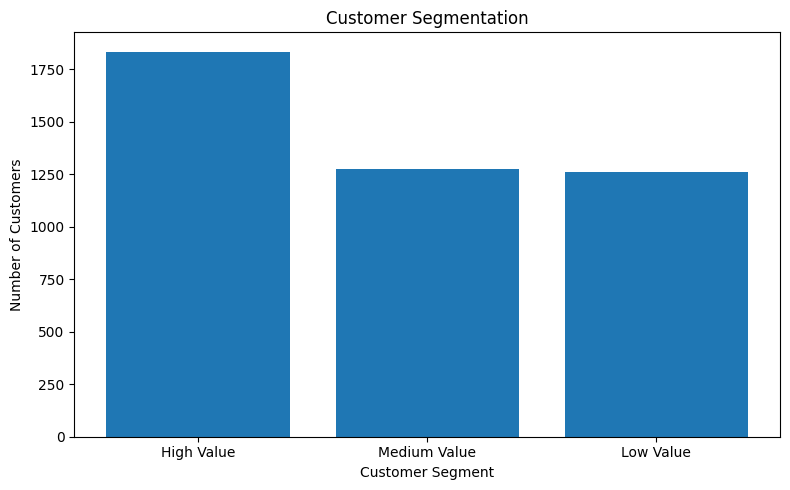

In [56]:
plt.figure(figsize=(8, 5))

plt.bar(
    segment_counts.index.astype(str),
    segment_counts.values
)

plt.title("Customer Segmentation")
plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()

In [57]:
customer_segment_data = customer_data.merge(
    rfm[["CustomerID", "Segment"]],
    on="CustomerID"
)

customer_segment_data.head()

,CustomerID,TotalRevenue,TotalOrders,TotalQuantity,Recency,Segment
0,12346,0.00,2,0,325,Low Value
1,12347,4310.00,7,2458,1,High Value
2,12348,1797.24,4,2341,74,High Value
3,12349,1757.55,1,631,18,High Value
4,12350,334.40,1,197,309,Low Value


In [58]:
segment_revenue = (
    customer_segment_data.groupby("Segment", observed=True)["TotalRevenue"]
    .sum()
)

print(segment_revenue)

Segment
Low Value        302605.280
Medium Value     849054.533
High Value      7126859.611
Name: TotalRevenue, dtype: float64


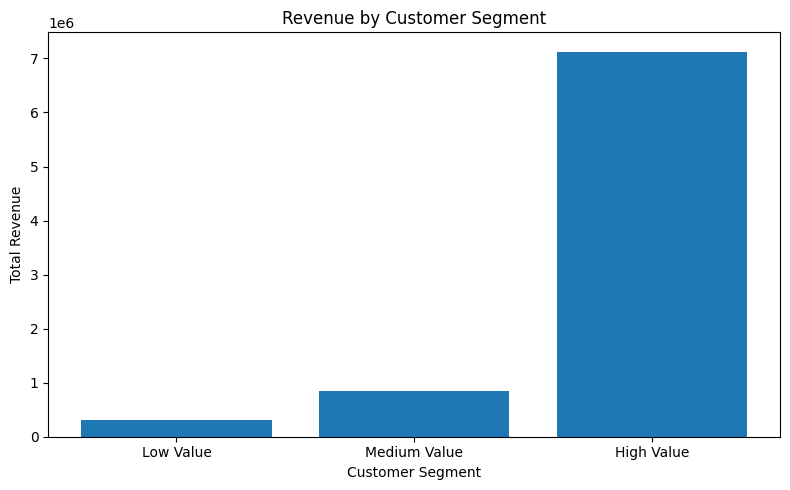

In [59]:
plt.figure(figsize=(8, 5))

plt.bar(
    segment_revenue.index.astype(str),
    segment_revenue.values
)

plt.title("Revenue by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Total Revenue")

plt.tight_layout()
plt.show()

In [60]:
segment_summary = (
    customer_segment_data.groupby("Segment", observed=True)
    .agg(
        NumberOfCustomers=("CustomerID", "count"),
        TotalRevenue=("TotalRevenue", "sum"),
        AverageRevenue=("TotalRevenue", "mean"),
        AverageOrders=("TotalOrders", "mean"),
        AverageRecency=("Recency", "mean")
    )
    .round(2)
)

print(segment_summary)

              NumberOfCustomers  TotalRevenue  AverageRevenue  AverageOrders  \
Segment                                                                        
Low Value                  1262     302605.28          239.78           1.26   
Medium Value               1276     849054.53          665.40           2.37   
High Value                 1834    7126859.61         3885.96           9.58   

              AverageRecency  
Segment                       
Low Value             192.78  
Medium Value           83.50  
High Value             26.29  


In [63]:
customer_segment_data.to_csv(
    "customer_segmentation_results.csv",
    index=False
)

In [64]:
segment_summary.to_csv(
    "segment_summary.csv"
)